# Giải thích *A micro Lie theory for state estimation in robotics* cho người mới bắt đầu

Notebook này biến các ý chính của paper thành trực giác + code chạy được.

Ta **cố ý chỉ làm việc trong 2D** với $SO(2)$ và $SE(2)$ để dễ nhìn hình, nhưng tinh thần hoàn toàn giống với các nhóm 3D như $SO(3)$, quaternion và $SE(3)$ trong paper.

## Sau notebook này, bạn nên nắm được

- vì sao pose/quay của robot **không nên** được cộng trừ như vector thường,
- manifold là gì, tangent space là gì, và vì sao roboticians thích làm việc trên tangent,
- ý nghĩa của `Exp`, `Log`, `plus`, `minus`, `adjoint`,
- vì sao Jacobian trong Lie theory vẫn giúp EKF/optimization trông gần giống dạng quen thuộc,
- cách viết một **mini error-state EKF trên $SE(2)$** với landmark.

> Mục tiêu ở đây là **hiểu** trước, tối ưu hoá và ký hiệu đầy đủ có thể học sau.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(7)

J2 = np.array([[0.0, -1.0],
               [1.0,  0.0]])

def wrap_angle(theta):
    return (theta + np.pi) % (2*np.pi) - np.pi

plt.rcParams["figure.figsize"] = (6, 5)

## 1) Vấn đề mở đầu: góc không sống tốt trong vector space thường

Ví dụ kinh điển:

- một robot có thể nhìn sang trái với góc $179^\circ$,
- robot khác gần như cùng hướng nhưng được ghi là $-179^\circ$.

Nếu lấy trung bình số học, ta được gần $0^\circ$, tức là quay sang phải — hoàn toàn sai trực giác.

Đây là dấu hiệu rằng trạng thái quay **sống trên một cấu trúc cong** (vòng tròn), chứ không phải trên đường thẳng Euclid thông thường.

Góc đầu vào: [ 179. -179.]
Trung bình số học: 0.0 độ
Trung bình "trên vòng tròn": 180.0 độ


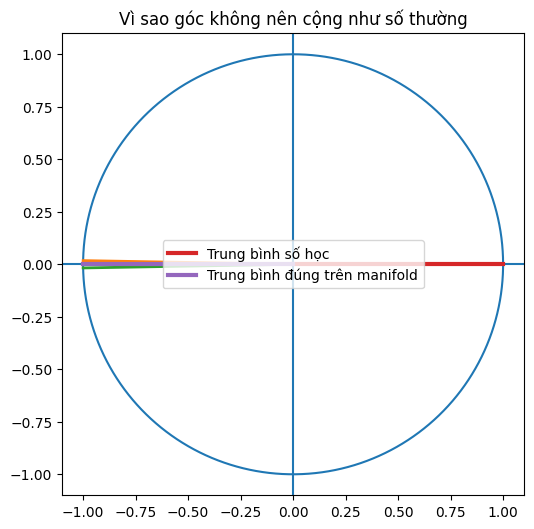

In [2]:
angles_deg = np.array([179.0, -179.0])
angles_rad = np.deg2rad(angles_deg)

naive_mean_deg = np.mean(angles_deg)

# Trung bình đúng trên vòng tròn: trung bình vector đơn vị rồi lấy atan2
z = np.exp(1j * angles_rad)
circular_mean_rad = np.angle(np.mean(z))
circular_mean_deg = np.rad2deg(circular_mean_rad)

print(f"Góc đầu vào: {angles_deg}")
print(f"Trung bình số học: {naive_mean_deg:.1f} độ")
print(f'Trung bình "trên vòng tròn": {circular_mean_deg:.1f} độ')

fig, ax = plt.subplots(figsize=(6,6))
t = np.linspace(0, 2*np.pi, 400)
ax.plot(np.cos(t), np.sin(t))
ax.axhline(0); ax.axvline(0)

for a in angles_rad:
    ax.plot([0, np.cos(a)], [0, np.sin(a)], linewidth=2)

ax.plot([0, np.cos(np.deg2rad(naive_mean_deg))],
        [0, np.sin(np.deg2rad(naive_mean_deg))],
        linewidth=3, label="Trung bình số học")

ax.plot([0, np.cos(circular_mean_rad)],
        [0, np.sin(circular_mean_rad)],
        linewidth=3, label="Trung bình đúng trên manifold")

ax.set_aspect("equal")
ax.set_title("Vì sao góc không nên cộng như số thường")
ax.legend()
plt.show()

## 2) Từ trực giác sang công cụ: $SO(2)$, $SE(2)$, `Exp`, `Log`, `plus`, `minus`

Ta dùng hai đối tượng:

- **$SO(2)$**: chỉ quay 2D.
- **$SE(2)$**: pose 2D của robot = quay + tịnh tiến.

Ta sẽ cài các hàm sau:

- `Exp`: từ một **bước nhỏ trong tangent** sang một phần tử hợp lệ trên manifold,
- `Log`: kéo ngược từ manifold về tangent,
- `plus`: cập nhật trạng thái, $X \oplus \tau = X \, \mathrm{Exp}(\tau)$,
- `minus`: lấy sai số, $Y \ominus X = \mathrm{Log}(X^{-1}Y)$,
- `adjoint`: đổi cách biểu diễn **cùng một perturbation** giữa local frame và global frame.

Trong notebook này, pose $SE(2)$ được lưu dưới dạng ma trận đồng nhất $3\times 3$:
$$
T = \begin{bmatrix}R & t \\ 0 & 1\end{bmatrix}.
$$

In [3]:
# ---------- SO(2) ----------
def exp_so2(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s],
                     [s,  c]])

def log_so2(R):
    return math.atan2(R[1, 0], R[0, 0])

# Ma trận V(theta) xuất hiện trong Exp của SE(2)
def V_so2(theta):
    if abs(theta) < 1e-8:
        return np.eye(2) + 0.5 * theta * J2 + (theta**2 / 6.0) * (J2 @ J2)
    a = math.sin(theta) / theta
    b = (1 - math.cos(theta)) / theta
    return a * np.eye(2) + b * J2

# ---------- SE(2) ----------
def exp_se2(xi):
    # xi = [rho_x, rho_y, theta] in R^3 (tangent coordinates)
    rho = np.asarray(xi[:2], dtype=float)
    theta = float(xi[2])
    R = exp_so2(theta)
    t = V_so2(theta) @ rho

    T = np.eye(3)
    T[:2, :2] = R
    T[:2, 2] = t
    return T

def inv_se2(T):
    R = T[:2, :2]
    t = T[:2, 2]
    Ti = np.eye(3)
    Ti[:2, :2] = R.T
    Ti[:2, 2] = -R.T @ t
    return Ti

def log_se2(T):
    R = T[:2, :2]
    t = T[:2, 2]
    theta = log_so2(R)
    rho = np.linalg.solve(V_so2(theta), t)
    return np.array([rho[0], rho[1], theta])

def compose_se2(A, B):
    return A @ B

def plus_se2(T, delta):
    return T @ exp_se2(delta)

def minus_se2(Y, X):
    return log_se2(inv_se2(X) @ Y)

def left_plus_se2(delta, T):
    return exp_se2(delta) @ T

def adjoint_se2(T):
    # Ad_T = [[R, -J t],
    #         [0,   1 ]]
    R = T[:2, :2]
    t = T[:2, 2]
    A = np.eye(3)
    A[:2, :2] = R
    A[:2, 2] = -(J2 @ t)
    return A

def action_se2(T, p):
    return T[:2, :2] @ p + T[:2, 2]

def pose_xytheta(T):
    x, y = T[:2, 2]
    theta = log_so2(T[:2, :2])
    return np.array([x, y, theta])

def plot_pose(ax, T, label=None, axis_len=0.35):
    x, y, theta = pose_xytheta(T)
    ax.plot(x, y, marker='o')
    ax.arrow(x, y,
             axis_len * np.cos(theta),
             axis_len * np.sin(theta),
             head_width=0.08, length_includes_head=True)
    if label is not None:
        ax.text(x + 0.05, y + 0.05, label)

def Jr_se2(xi):
    """
    Right Jacobian of SE(2), Appendix C in the paper.
    xi = [rho_x, rho_y, theta]
    """
    rho1, rho2, theta = map(float, xi)

    if abs(theta) < 1e-6:
        return np.array([
            [1 - theta**2/6.0,
             theta/2.0 - theta**3/24.0,
             -rho2/2.0 + rho1*theta/6.0 + rho2*theta**2/24.0],
            [-theta/2.0 + theta**3/24.0,
             1 - theta**2/6.0,
             rho1/2.0 + rho2*theta/6.0 - rho1*theta**2/24.0],
            [0.0, 0.0, 1.0]
        ])

    s = math.sin(theta)
    c = math.cos(theta)
    return np.array([
        [s/theta, (1-c)/theta, (theta*rho1 - rho2 + rho2*c - rho1*s)/(theta**2)],
        [(c-1)/theta, s/theta, (rho1 + theta*rho2 - rho1*c - rho2*s)/(theta**2)],
        [0.0, 0.0, 1.0]
    ])

def numeric_jacobian_pose_action(T, p, eps=1e-7):
    J = np.zeros((2, 3))
    y0 = action_se2(T, p)
    for i in range(3):
        d = np.zeros(3)
        d[i] = eps
        y1 = action_se2(plus_se2(T, d), p)
        J[:, i] = (y1 - y0) / eps
    return J

def analytic_jacobian_pose_action(T, p):
    R = T[:2, :2]
    return np.column_stack([R, R @ J2 @ p])

def h_landmark(T, b):
    """
    Landmark observed in robot frame:
    y = R^T (b - t)
    """
    R = T[:2, :2]
    t = T[:2, 2]
    return R.T @ (b - t)

def H_landmark(T, b):
    """
    Measurement Jacobian used in the paper, Section V-A:
    H = - [I, R^T J (b - t)]
    """
    R = T[:2, :2]
    t = T[:2, 2]
    return -np.column_stack([np.eye(2), R.T @ J2 @ (b - t)])

## 3) `Exp` và `Log`: đi qua lại giữa tangent và manifold

Bạn có thể nghĩ đơn giản như sau:

- tangent space là nơi ta lưu **vector nhỏ** và covariance,
- manifold là nơi ta lưu **trạng thái hợp lệ của robot**,
- `Exp` đưa vector nhỏ thành một pose hợp lệ,
- `Log` kéo một pose tương đối về lại vector nhỏ.

Nếu code đúng, `Log(Exp(xi))` phải trả lại gần `xi`.

In [4]:
tests = [
    np.array([0.3, -0.1, 0.0]),
    np.array([1.0,  0.5, 0.3]),
    np.array([0.1, -0.2, -1.0]),
]

for xi in tests:
    recovered = log_se2(exp_se2(xi))
    print("xi      =", xi)
    print("Log(Exp)=", recovered)
    print("sai số  =", np.linalg.norm(xi - recovered))
    print("-" * 50)

xi      = [ 0.3 -0.1  0. ]
Log(Exp)= [ 0.3 -0.1  0. ]
sai số  = 0.0
--------------------------------------------------
xi      = [1.  0.5 0.3]
Log(Exp)= [1.  0.5 0.3]
sai số  = 1.1102230246251565e-16
--------------------------------------------------
xi      = [ 0.1 -0.2 -1. ]
Log(Exp)= [ 0.1 -0.2 -1. ]
sai số  = 3.1031676915590914e-17
--------------------------------------------------


## 4) `plus` và `minus`: update state và lấy error

Đây là phần rất thực dụng:

- cập nhật state: `X_new = X ⊕ delta`
- lấy sai số giữa hai state: `delta = Y ⊖ X`

Ta sẽ kiểm tra hai điều:

1. nếu lấy `Y = X ⊕ delta`, thì `Y ⊖ X` phải khôi phục lại `delta`;
2. cùng một perturbation nếu viết ở local frame hay global frame thì liên hệ với nhau qua **adjoint**.

delta_local gốc           = [ 0.2    -0.05    0.1396]
delta khôi phục bằng minus = [ 0.2    -0.05    0.1396]

Sai số giữa update local và global sau khi dùng adjoint:
1.3877787807814457e-17


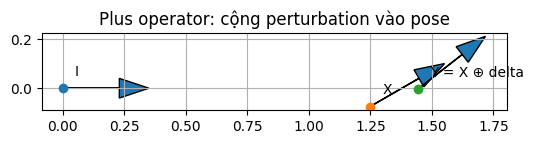

In [5]:
X = exp_se2(np.array([1.2, -0.4, np.deg2rad(30)]))
delta_local = np.array([0.2, -0.05, np.deg2rad(8)])

Y = plus_se2(X, delta_local)
delta_recovered = minus_se2(Y, X)

print("delta_local gốc           =", delta_local)
print("delta khôi phục bằng minus =", delta_recovered)
print()

# Cùng một perturbation nhưng đổi từ local sang global qua adjoint
delta_global = adjoint_se2(X) @ delta_local

Y_right = plus_se2(X, delta_local)          # X ⊕ delta_local
Y_left  = left_plus_se2(delta_global, X)    # (Ad_X delta_local) ⊕_left X

print("Sai số giữa update local và global sau khi dùng adjoint:")
print(np.max(np.abs(Y_right - Y_left)))

fig, ax = plt.subplots(figsize=(6,6))
plot_pose(ax, np.eye(3), "I")
plot_pose(ax, X, "X")
plot_pose(ax, Y, "Y = X ⊕ delta")
ax.set_aspect("equal")
ax.set_title("Plus operator: cộng perturbation vào pose")
ax.grid(True)
plt.show()

### Trực giác của adjoint

`adjoint` không phải là "một perturbation khác". Nó là **cùng chuyển động nhỏ đó**, nhưng được mô tả trong hệ tọa độ khác.

Ví dụ:

- nếu robot tự tiến lên 10 cm theo trục thân xe, đó là perturbation local;
- nhìn từ hệ world, cùng bước 10 cm này sẽ có hướng khác tùy robot đang quay bao nhiêu độ.

Adjoint chính là bộ đổi tọa độ đó.

## 5) Tích phân chuyển động trên manifold

Paper viết rất gọn:
$$
X_k = X_{k-1} \oplus \tau_k = X_{k-1}\,\mathrm{Exp}(\tau_k).
$$

Nghĩa là:

1. lấy control / twist nhỏ $\tau_k$ trong tangent,
2. dùng `Exp` để biến nó thành increment hợp lệ,
3. nhân vào pose hiện tại.

Bên dưới là một quỹ đạo robot 2D được tạo đúng theo ý tưởng này.

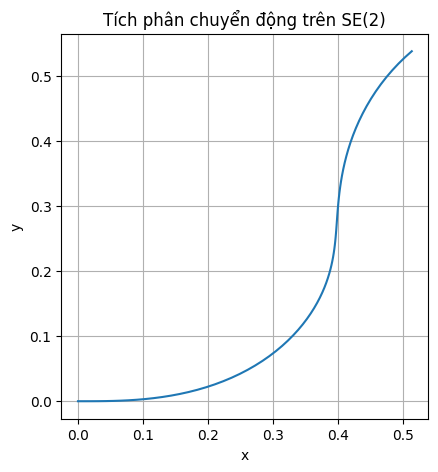

In [6]:
def simulate_controls(num_steps=80, dt=0.1):
    controls = []
    for k in range(num_steps):
        v = 0.10 + 0.04 * np.sin(0.1 * k)
        w = 0.45 * np.sin(0.06 * k)
        controls.append(np.array([v * dt, 0.0, w * dt]))
    return controls

controls = simulate_controls()
T = np.eye(3)
traj = [T[:2, 2].copy()]

for u in controls:
    T = plus_se2(T, u)
    traj.append(T[:2, 2].copy())

traj = np.array(traj)

fig, ax = plt.subplots()
ax.plot(traj[:, 0], traj[:, 1])
ax.set_aspect("equal")
ax.set_title("Tích phân chuyển động trên SE(2)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(True)
plt.show()

## 6) Jacobian: đạo hàm, nhưng viết trên tangent space

Trong vector space thường, Jacobian nói: "nếu input đổi rất nhỏ, output đổi xấp xỉ thế nào".

Trên manifold cũng vậy, chỉ khác là:

- input perturbation được đo trong tangent space của input,
- output perturbation được đo trong tangent space của output.

Ta xét hàm rất hay dùng trong robotics:
$$
y = T \cdot p = Rp + t.
$$

Paper cho Jacobian theo pose:
$$
\frac{\partial (T\cdot p)}{\partial T}
=
\begin{bmatrix}
R & R J p
\end{bmatrix},
$$
với $J = \begin{bmatrix}0 & -1\\1 & 0\end{bmatrix}$ trong 2D.

Ta sẽ kiểm tra công thức này bằng sai phân hữu hạn.

In [7]:
T = exp_se2(np.array([1.0, 0.3, np.deg2rad(25)]))
p = np.array([2.0, -0.5])

J_analytic = analytic_jacobian_pose_action(T, p)
J_numeric  = numeric_jacobian_pose_action(T, p, eps=1e-7)

print("Jacobian giải tích:")
print(J_analytic)
print()
print("Jacobian sai phân hữu hạn:")
print(J_numeric)
print()
print("Chuẩn sai khác:", np.linalg.norm(J_analytic - J_numeric))

Jacobian giải tích:
[[ 0.9063 -0.4226 -0.3921]
 [ 0.4226  0.9063  2.0239]]

Jacobian sai phân hữu hạn:
[[ 0.9063 -0.4226 -0.3921]
 [ 0.4226  0.9063  2.0239]]

Chuẩn sai khác: 1.0263352517554778e-07


## 7) Uncertainty: covariance phải nằm trên tangent, không phải trên ma trận pose

Đây là một ý rất quan trọng của paper.

Ta **không** đặt Gaussian trực tiếp lên các phần tử của ma trận quay / pose.

Thay vào đó:

1. chọn một mean pose $\bar X$ trên manifold,
2. lấy nhiễu nhỏ $\tau \sim \mathcal N(0, \Sigma)$ trong tangent,
3. tạo sample bằng
   $$
   X = \bar X \oplus \tau.
   $$

Ta thử lấy nhiều mẫu như vậy để nhìn "đám mây pose" quanh một mean pose.

Covariance đặt trong tangent (mục tiêu):
[[0.04   0.     0.    ]
 [0.     0.0064 0.    ]
 [0.     0.     0.0439]]

Covariance ước lượng lại từ sample tangent:
[[ 0.0349 -0.0007  0.0008]
 [-0.0007  0.0059  0.0006]
 [ 0.0008  0.0006  0.0413]]


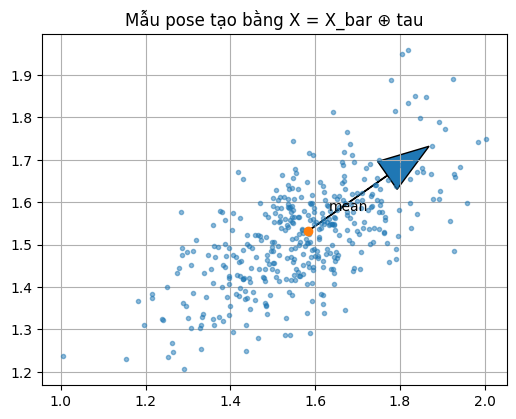

In [8]:
X_bar = exp_se2(np.array([2.0, 1.0, np.deg2rad(35)]))
Sigma = np.diag([0.20**2, 0.08**2, np.deg2rad(12)**2])

samples = []
eps_samples = rng.multivariate_normal(np.zeros(3), Sigma, size=400)
for eps in eps_samples:
    samples.append(plus_se2(X_bar, eps))
samples = np.array(samples)

origins = samples[:, :2, 2]
sample_tangent = np.array([minus_se2(T, X_bar) for T in samples])

print("Covariance đặt trong tangent (mục tiêu):")
print(Sigma)
print()
print("Covariance ước lượng lại từ sample tangent:")
print(np.cov(sample_tangent.T))

fig, ax = plt.subplots()
ax.plot(origins[:, 0], origins[:, 1], linestyle='none', marker='.', alpha=0.5)
plot_pose(ax, X_bar, label="mean")
ax.set_aspect("equal")
ax.set_title("Mẫu pose tạo bằng X = X_bar ⊕ tau")
ax.grid(True)
plt.show()

## 8) Mini error-state EKF trên $SE(2)$ với landmark

Đây là phần mô phỏng gần với ứng dụng trong paper nhất.

### State
Ta ước lượng pose robot $X \in SE(2)$.

### Prediction
Dùng control nhỏ $u_k \in \mathbb{R}^3$:
$$
\hat X_k = \hat X_{k-1} \oplus u_k
$$

Covariance nằm trong tangent:
$$
P_k \approx F P_{k-1} F^\top + GQG^\top
$$

với:

- $F = \mathrm{Ad}_{\mathrm{Exp}(u_k)}^{-1}$
- $G = J_r(u_k)$

### Measurement
Landmark $b$ được quan sát trong frame robot:
$$
y = R^\top (b - t) + n
$$

Jacobian đo:
$$
H = -\begin{bmatrix} I & R^\top J (b - t)\end{bmatrix}.
$$

Bản demo dưới đây dùng dữ liệu giả lập, nhưng nó giữ đúng tinh thần của Section V-A trong paper.

Sai số pose cuối cùng trong tangent [dx, dy, dtheta]:
[ 0.0271 -0.0268  0.0005]

RMSE vị trí trên toàn quỹ đạo: 0.04118326474359876

Đường chéo covariance cuối:
[0.0008 0.0013 0.0001]


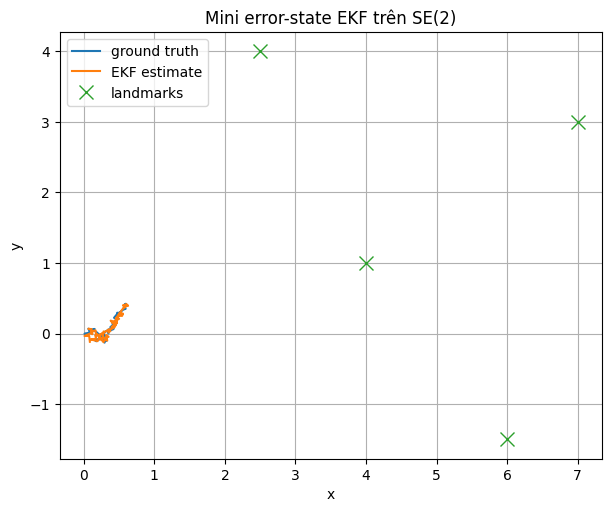

In [9]:
# ----- Mô phỏng dữ liệu -----
landmarks = np.array([
    [4.0,  1.0],
    [6.0, -1.5],
    [2.5,  4.0],
    [7.0,  3.0],
])

Q = np.diag([0.03**2, 0.02**2, np.deg2rad(2.0)**2])   # noise của control trong tangent
R_meas = np.diag([0.08**2, 0.08**2])                  # noise đo landmark

steps = 80
dt = 0.1

X_true = np.eye(3)
X_hat  = exp_se2(np.array([0.5, -0.4, np.deg2rad(12)]))  # cố tình khởi tạo lệch
P = np.diag([0.5**2, 0.5**2, np.deg2rad(20)**2])

true_traj = []
est_traj = []

for k in range(steps):
    # command danh nghĩa
    v = 0.12 + 0.04 * np.sin(0.10 * k)
    w = 0.25 * np.sin(0.07 * k)
    u_nom = np.array([v * dt, 0.0, w * dt])

    # robot thật nhận control bị nhiễu
    u_real = u_nom + rng.multivariate_normal(np.zeros(3), Q)
    X_true = plus_se2(X_true, u_real)

    # filter dùng control đo được (ở demo này ta cho bằng u_real để tập trung vào Lie update)
    u_meas = u_real

    # ----- Prediction -----
    X_hat = plus_se2(X_hat, u_meas)
    F = np.linalg.inv(adjoint_se2(exp_se2(u_meas)))
    G = Jr_se2(u_meas)
    P = F @ P @ F.T + G @ Q @ G.T

    # ----- Measurement updates -----
    for b in landmarks:
        y = h_landmark(X_true, b) + rng.multivariate_normal(np.zeros(2), R_meas)
        y_hat = h_landmark(X_hat, b)

        z = y - y_hat
        H = H_landmark(X_hat, b)
        S = H @ P @ H.T + R_meas
        K = P @ H.T @ np.linalg.inv(S)

        delta = K @ z
        X_hat = plus_se2(X_hat, delta)
        P = P - K @ S @ K.T
        P = 0.5 * (P + P.T)  # ép đối xứng số học

    true_traj.append(X_true[:2, 2].copy())
    est_traj.append(X_hat[:2, 2].copy())

true_traj = np.array(true_traj)
est_traj = np.array(est_traj)

final_error = minus_se2(X_hat, X_true)
rmse = np.sqrt(np.mean(np.sum((true_traj - est_traj)**2, axis=1)))

print("Sai số pose cuối cùng trong tangent [dx, dy, dtheta]:")
print(final_error)
print()
print("RMSE vị trí trên toàn quỹ đạo:", rmse)
print()
print("Đường chéo covariance cuối:")
print(np.diag(P))

fig, ax = plt.subplots(figsize=(7,6))
ax.plot(true_traj[:, 0], true_traj[:, 1], label="ground truth")
ax.plot(est_traj[:, 0], est_traj[:, 1], label="EKF estimate")
ax.plot(landmarks[:, 0], landmarks[:, 1], linestyle='none', marker='x', markersize=10, label="landmarks")
ax.set_aspect("equal")
ax.set_title("Mini error-state EKF trên SE(2)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(True)
ax.legend()
plt.show()

## 9) Gom lại tinh thần của paper trong 5 câu

1. **State của robot thường nằm trên manifold**, không phải vector space thường.
2. **Ta làm vi phân và Gaussian trong tangent space**, vì tangent là không gian phẳng, dễ tính.
3. **`Exp`/`Log` là cầu nối** giữa "vector perturbation" và "state hợp lệ".
4. **Jacobian, EKF, tối ưu hóa vẫn gần giống công thức quen thuộc**, chỉ khác là mọi sai số/covariance phải được viết đúng trên tangent.
5. Khi quen tư duy này trong 2D, bạn có thể nâng thẳng lên **SO(3), quaternion, SE(3), VIO, SLAM, bundle adjustment**.

---

### Nếu bạn muốn học tiếp sau notebook này

Một lộ trình rất hợp lý là:

- làm lại toàn bộ notebook nhưng thay $SE(2)$ bằng $SO(3)$,
- tự cài `Exp/Log` cho rotation 3D,
- kiểm tra Jacobian bằng finite difference như ở trên,
- sau đó mới đọc lại phần quaternion / $SE(3)$ của paper.

Đó là lúc paper sẽ "dễ thở" hơn rất nhiều.